<a href="https://colab.research.google.com/github/DaltonML/DeepLearningColab/blob/main/LeNetMNist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#=============================================================================AlexNet====================================================================================#
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import backend as K
from keras import utils as utls
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense

In [2]:
# Definição de Hiperparâmetros
imageRows, imageCols = 28, 28
batchSize = 256
numClasses = 10
epochs = 10
cores = 1

In [3]:
(XTrain, yTrain), (XTest, yTest) = mnist.load_data()
XTrain = XTrain.astype('float32')
XTest = XTest.astype('float32')
XTrain = XTrain / 255.0
XTest = XTest / 255.0
yTrain = utls.to_categorical(yTrain, numClasses)
yTest = utls.to_categorical(yTest, numClasses)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
XTrain.shape

(60000, 28, 28)

In [5]:
inputShape = (imageRows, imageCols, cores)

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', input_shape=inputShape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(256))
model.add(Activation('relu'))

model.add(Dense(numClasses))
model.add(Activation('softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
minhaAlexNetModel = model.fit(XTrain, yTrain, batch_size=batchSize, epochs=epochs, validation_data=(XTest, yTest))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 488ms/step - accuracy: 0.9395 - loss: 0.1980 - val_accuracy: 0.9822 - val_loss: 0.0530
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 479ms/step - accuracy: 0.9860 - loss: 0.0462 - val_accuracy: 0.9890 - val_loss: 0.0300
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 475ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9878 - val_loss: 0.0344
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 112s 479ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9927 - val_loss: 0.0247
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 473ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9887 - val_loss: 0.0332
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 111s 475ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9925 - val_loss: 0.0231
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 117s 495ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9895 - val_loss: 0.0322
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 111s 473ms/step - accuracy: 0.9973 -

In [9]:
loss, acc = model.evaluate(XTest, yTest)

print("Loss:", loss)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9929 - loss: 0.0248
Loss: 0.024836774915456772
Accuracy: 0.992900013923645


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [11]:
predicoes = model.predict(XTest)

y_pred = np.argmax(predicoes, axis=1)
y_real = np.argmax(yTest, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step


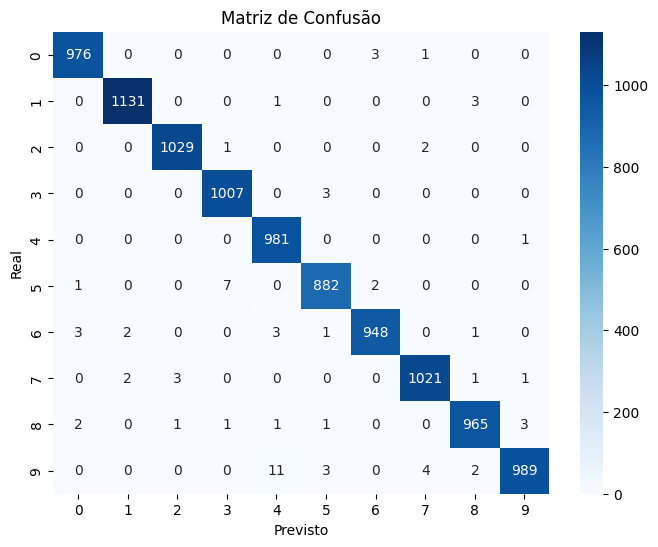

In [12]:
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

Text(0, 0.5, 'Acurácia')

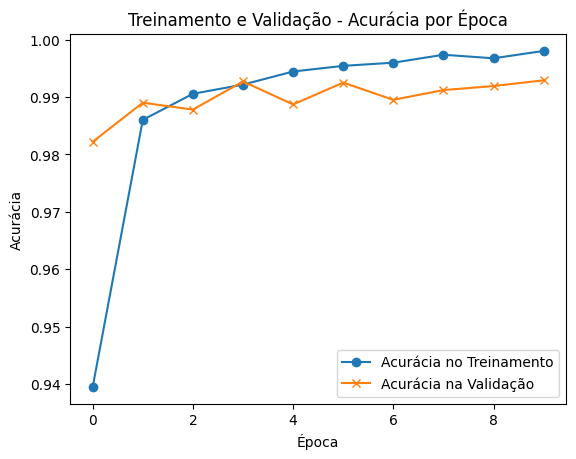

In [15]:
f, ax = plt.subplots()
ax.plot(minhaAlexNetModel.history['accuracy'], 'o-')
ax.plot(minhaAlexNetModel.history['val_accuracy'], 'x-')
ax.legend(['Acurácia no Treinamento', 'Acurácia na Validação'], loc=0)
ax.set_title('Treinamento e Validação - Acurácia por Época')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia')

In [16]:
#==========================================================================Arquitetura VGG===========================================================================================#
model = Sequential()

model.add(Conv2D(32,(3,3),padding='same',
                 activation='relu',
                 input_shape=inputShape))
model.add(Conv2D(32,(3,3),padding='same',
                 activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),padding='same',
                 activation='relu'))
model.add(Conv2D(64,(3,3),padding='same',
                 activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))

model.add(Dense(numClasses,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,634 (3.32 MB)

 Trainable params: 870,634 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
minhaVGGModel = model.fit(XTrain, yTrain, batch_size=batchSize, epochs=epochs, validation_data=(XTest, yTest))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9315 - loss: 0.2214 - val_accuracy: 0.9833 - val_loss: 0.0537
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9861 - loss: 0.0454 - val_accuracy: 0.9899 - val_loss: 0.0279
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9910 - val_loss: 0.0280
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9915 - val_loss: 0.0261
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9943 - loss: 0.0171 - val_accuracy: 0.9906 - val_loss: 0.0288
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9959 - loss: 0.0132 - val_accuracy: 0.9916 - val_loss: 0.0264
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.9971 - loss: 0.0096 - val_accuracy: 0.9917 - val_loss: 0.0284
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.9970 - loss: 0.0088 - val_accu

In [19]:
loss, acc = model.evaluate(XTest, yTest)

print("Loss:", loss)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9923 - loss: 0.0288
Loss: 0.028836090117692947
Accuracy: 0.9922999739646912


In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [21]:
predicoes = model.predict(XTest)

y_pred = np.argmax(predicoes, axis=1)
y_real = np.argmax(yTest, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step


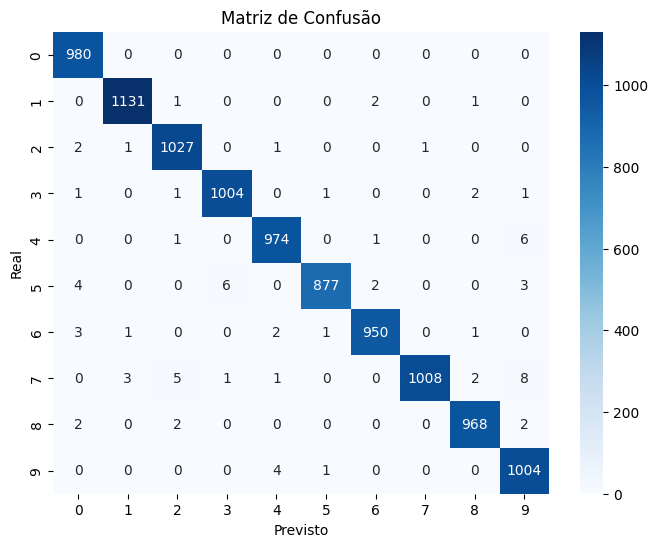

In [22]:
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

Text(0, 0.5, 'Acurácia')

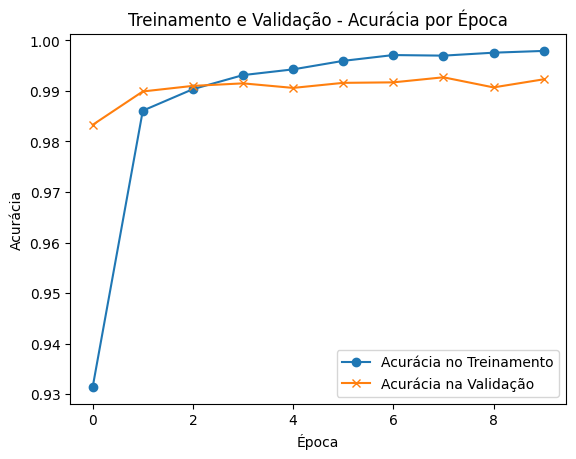

In [23]:
f, ax = plt.subplots()
ax.plot(minhaVGGModel.history['accuracy'], 'o-')
ax.plot(minhaVGGModel.history['val_accuracy'], 'x-')
ax.legend(['Acurácia no Treinamento', 'Acurácia na Validação'], loc=0)
ax.set_title('Treinamento e Validação - Acurácia por Época')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia')

In [24]:
#============================================================================LeNet=====================================================================================#

model = Sequential()
model.add(Conv2D(20, (5,5), padding='same', input_shape=inputShape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Conv2D(50, (5,5), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Flatten())
model.add(Dense(500))
model.add(Activation('relu'))
model.add(Dense(numClasses))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 20)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 28, 28, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 50)     │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2450)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │     1,225,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,256,080 (4.79 MB)

 Trainable params: 1,256,080 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
minhaLeNetModel = model.fit(XTrain, yTrain, batch_size=batchSize, epochs=epochs, validation_data=(XTest, yTest))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 120s 505ms/step - accuracy: 0.9377 - loss: 0.2119 - val_accuracy: 0.9825 - val_loss: 0.0537
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 137s 483ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9876 - val_loss: 0.0375
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 142s 483ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9894 - val_loss: 0.0301
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 118s 505ms/step - accuracy: 0.9917 - loss: 0.0261 - val_accuracy: 0.9911 - val_loss: 0.0260
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 137s 482ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9911 - val_loss: 0.0264
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 114s 487ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accuracy: 0.9904 - val_loss: 0.0292
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 482ms/step - accuracy: 0.9956 - loss: 0.0136 - val_accuracy: 0.9888 - val_loss: 0.0344
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 118s 503ms/step - accuracy: 0.9962 -

In [27]:
loss, acc = model.evaluate(XTest, yTest)

print("Loss:", loss)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9923 - loss: 0.0243
Loss: 0.02429763600230217
Accuracy: 0.9922999739646912


In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [29]:
predicoes = model.predict(XTest)

y_pred = np.argmax(predicoes, axis=1)
y_real = np.argmax(yTest, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


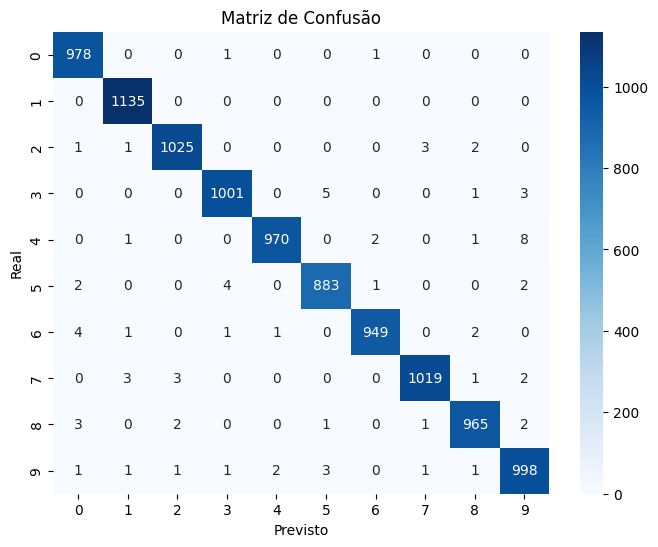

In [30]:
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

Text(0, 0.5, 'Acurácia')

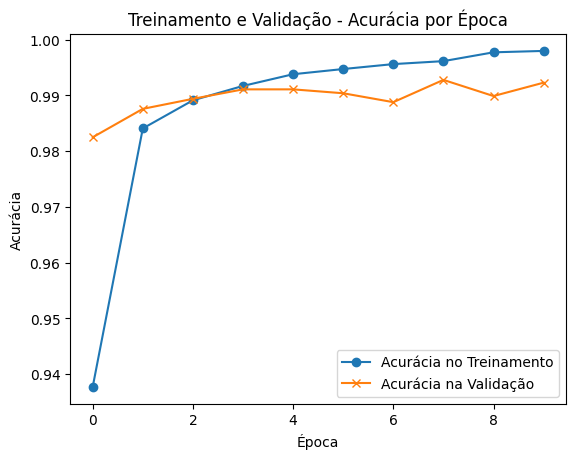

In [31]:
f, ax = plt.subplots()
ax.plot(minhaLeNetModel.history['accuracy'], 'o-')
ax.plot(minhaLeNetModel.history['val_accuracy'], 'x-')
ax.legend(['Acurácia no Treinamento', 'Acurácia na Validação'], loc=0)
ax.set_title('Treinamento e Validação - Acurácia por Época')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia')